In [1]:
# Month 2 Week 3 — REST APIs and Live Financial Data

In [2]:
#The Open Exchange Rates API returns currency data with no authentication:
import requests
import json

# Make a GET request to a public API
url = "https://open.er-api.com/v6/latest/USD"
response = requests.get(url) #sends the HTTP request

# Check status
print("Status code:", response.status_code)  # 200 = success

# Parse JSON response
data = response.json() #parses the response text into a python dict
print("Base currency:", data["base_code"])
print("SGD rate:", data["rates"]["SGD"])
print("JPY rate:", data["rates"]["JPY"])
print("EUR rate:", data["rates"]["EUR"])

Status code: 200
Base currency: USD
SGD rate: 1.286543
JPY rate: 160.163002
EUR rate: 0.865342


In [3]:
# JSON response from a typical financial API looks like this:
sample_response = {
    "ticker": "SPY",
    "results": [
        {
            "o": 498.20,   # open
            "h": 501.45,   # high
            "l": 497.80,   # low
            "c": 500.12,   # close
            "v": 82341209, # volume
            "t": 1704067200000  # timestamp (milliseconds)
        },
        {
            "o": 500.12,
            "h": 503.20,
            "l": 499.50,
            "c": 502.88,
            "v": 76234100,
            "t": 1704153600000
        }
    ]
}

# Access data the same way as a Python dict
print("Ticker:", sample_response["ticker"])
print("First bar close:", sample_response["results"][0]["c"])
print("Number of bars:", len(sample_response["results"]))

# Convert to pandas DataFrame
import pandas as pd
bars = pd.DataFrame(sample_response["results"])
print("\n", bars)
#ℹ The timestamp field (t) is in milliseconds since 1970 — called Unix time. Convert it with pd.to_datetime(df['t'], unit='ms') to get readable dates.

Ticker: SPY
First bar close: 500.12
Number of bars: 2

         o       h      l       c         v              t
0  498.20  501.45  497.8  500.12  82341209  1704067200000
1  500.12  503.20  499.5  502.88  76234100  1704153600000


In [4]:
# first authenticated API call
import requests
import pandas as pd

# Replace with your actual keys — never commit these to GitHub
API_KEY    = "YOUR_API_KEY_HERE"
SECRET_KEY = "YOUR_SECRET_KEY_HERE"
BASE_URL   = "https://paper-api.alpaca.markets"

# Headers carry your authentication on every request
headers = {
    "APCA-API-KEY-ID":     API_KEY,
    "APCA-API-SECRET-KEY": SECRET_KEY
}

# Fetch account information
response = requests.get(
    f"{BASE_URL}/v2/account",
    headers=headers
)

print("Status:", response.status_code)
account = response.json()
print("Account status:", account["status"])
print("Portfolio value:", account["portfolio_value"])
print("Buying power:   ", account["buying_power"])

Status: 200
Account status: ACTIVE
Portfolio value: 100000
Buying power:    400000


In [5]:
#Pull historical price bars from Alpaca
from datetime import datetime, timedelta

# Data API uses a different base URL
DATA_URL = "https://data.alpaca.markets"

# Date range — last 30 days
end   = datetime.now().strftime("%Y-%m-%d")
start = (datetime.now() - timedelta(days=30)).strftime("%Y-%m-%d")

response = requests.get(
    f"{DATA_URL}/v2/stocks/SPY/bars",
    headers=headers,
    params={
        "timeframe": "1Day",
        "start":     start,
        "end":       end,
        "limit":     50,
        "feed":      "iex"  
    }
)

print("Status:", response.status_code)
data = response.json()
bars = pd.DataFrame(data["bars"])
bars["t"] = pd.to_datetime(bars["t"])
bars = bars.set_index("t")
bars = bars.rename(columns={
    "c":"close","h":"high","l":"low",
    "o":"open","v":"volume","vw":"vwap","n":"trades"
})
print(bars.tail())

Status: 200
                            close    high     low  trades    open   volume  \
t                                                                            
2026-06-01 04:00:00+00:00  758.44  760.26  754.74   24204  755.56  1446621   
2026-06-02 04:00:00+00:00  759.47  760.40  756.75   20441  757.21  1164371   
2026-06-03 04:00:00+00:00  754.18  758.79  753.59   29308  758.20  1906675   
2026-06-04 04:00:00+00:00  756.97  758.30  751.47   26881  752.06  1546700   
2026-06-05 04:00:00+00:00  737.45  752.80  735.59   46592  752.29  2829329   

                                 vwap  
t                                      
2026-06-01 04:00:00+00:00  757.541871  
2026-06-02 04:00:00+00:00  758.987478  
2026-06-03 04:00:00+00:00  755.410855  
2026-06-04 04:00:00+00:00  756.057324  
2026-06-05 04:00:00+00:00  743.138073  


In [6]:
#handle pagination - fetching large datasets
def fetch_all_bars(ticker, start, end, timeframe="1Day"):
    """Fetch all bars handling pagination automatically."""
    all_bars = [] #empty list
    url = f"{DATA_URL}/v2/stocks/{ticker}/bars"
    params = {
        "timeframe": timeframe,
        "start":     start,
        "end":       end,
        "limit":     1000,
        "feed":      "iex"    # free tier fix
    }
    #fetch a page, check if there's a next_page_token, if yes fetch the next page, repeat until None.
    while True:
        response = requests.get(url, headers=headers, params=params)
        data = response.json()
        bars = data.get("bars", [])
        
        if not bars:
            print("No bars returned. Response:", data)
            break
            
        all_bars.extend(bars)
        next_token = data.get("next_page_token")
        if not next_token:
            break
        params["page_token"] = next_token
        print(f"Fetched {len(all_bars)} bars so far...")

    if not all_bars:
        raise Exception("No data returned — check ticker, date range and API key")

    df = pd.DataFrame(all_bars)
    df["t"] = pd.to_datetime(df["t"])
    return df.set_index("t")

# Test it
spy_bars = fetch_all_bars("SPY", start, end)
print(f"Total bars fetched: {len(spy_bars)}")
print(spy_bars.tail())

Total bars fetched: 21
                                c       h       l      n       o        v  \
t                                                                           
2026-06-01 04:00:00+00:00  758.44  760.26  754.74  24204  755.56  1446621   
2026-06-02 04:00:00+00:00  759.47  760.40  756.75  20441  757.21  1164371   
2026-06-03 04:00:00+00:00  754.18  758.79  753.59  29308  758.20  1906675   
2026-06-04 04:00:00+00:00  756.97  758.30  751.47  26881  752.06  1546700   
2026-06-05 04:00:00+00:00  737.45  752.80  735.59  46592  752.29  2829329   

                                   vw  
t                                      
2026-06-01 04:00:00+00:00  757.541871  
2026-06-02 04:00:00+00:00  758.987478  
2026-06-03 04:00:00+00:00  755.410855  
2026-06-04 04:00:00+00:00  756.057324  
2026-06-05 04:00:00+00:00  743.138073  


In [8]:
#Build a clean MarketData class
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta

class MarketData:
    """Fetches and processes market data from Alpaca API."""

    def __init__(self, api_key, secret_key):
        self.headers = {
            "APCA-API-KEY-ID":     api_key,
            "APCA-API-SECRET-KEY": secret_key
        }
        self.data_url = "https://data.alpaca.markets"

    def get_bars(self, ticker, days=365):
        """Fetch daily OHLCV bars for a ticker."""
        end   = datetime.now().strftime("%Y-%m-%dT%H:%M:%SZ")
        start = (datetime.now()-timedelta(days=days)).strftime("%Y-%m-%dT%H:%M:%SZ")

        response = requests.get(
            f"{self.data_url}/v2/stocks/{ticker}/bars",
            headers=self.headers,
            params={
                "timeframe": "1Day",
                "start":     start,
                "end":       end,
                "limit":     1000,
                "feed":      "iex"    # free tier
            }
        )
        if response.status_code != 200:
            raise Exception(f"API error {response.status_code}: {response.text}")

        bars = pd.DataFrame(response.json()["bars"])
        bars["t"] = pd.to_datetime(bars["t"])
        bars = bars.set_index("t").rename(columns={
            "c":"close","h":"high","l":"low",
            "o":"open","v":"volume","vw":"vwap","n":"trades"
        })
        return bars[["open","high","low","close","volume"]]

    def get_signals(self, ticker, days=365):
        """Fetch bars and compute MA crossover signals."""
        bars = self.get_bars(ticker, days)
        bars["ma50"]    = bars["close"].rolling(50).mean()
        bars["ma200"]   = bars["close"].rolling(200).mean()
        bars["signal"]  = (bars["ma50"] > bars["ma200"]).astype(int)
        bars["returns"] = bars["close"].pct_change()
        bars["strategy"]= bars["returns"] * bars["signal"].shift(1)
        return bars.dropna()

# Use the class
md = MarketData(API_KEY, SECRET_KEY)
spy_data = md.get_signals("SPY")
print(spy_data[["close","ma50","ma200","signal","strategy"]].tail(8))

                            close      ma50      ma200  signal  strategy
t                                                                       
2026-05-27 04:00:00+00:00  750.59  700.0260  679.98810       1  0.000173
2026-05-28 04:00:00+00:00  754.68  701.7046  680.58220       1  0.005449
2026-05-29 04:00:00+00:00  756.34  703.6006  681.15075       1  0.002200
2026-06-01 04:00:00+00:00  758.44  705.5720  681.71835       1  0.002777
2026-06-02 04:00:00+00:00  759.47  707.7918  682.29120       1  0.001358
2026-06-03 04:00:00+00:00  754.18  709.7680  682.84450       1 -0.006965
2026-06-04 04:00:00+00:00  756.97  711.8434  683.41330       1  0.003699
2026-06-05 04:00:00+00:00  737.45  713.4576  683.90180       1 -0.025787



--- MA Strategy (live data) ---
Total Return:    12.29%
Ann. Return:     58.40%
Sharpe Ratio:    3.66
Max Drawdown:    -3.76%

--- Buy & Hold SPY (live data) ---
Total Return:    12.90%
Ann. Return:     61.08%
Sharpe Ratio:    3.84
Max Drawdown:    -3.76%


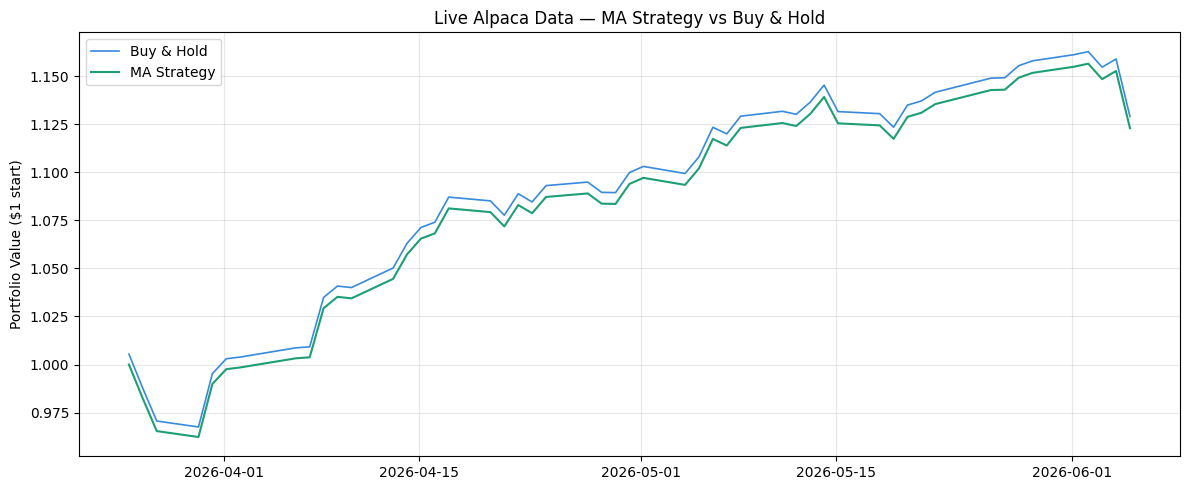

In [9]:
import matplotlib.pyplot as plt

def performance_report(returns, name):
    total  = (1+returns).cumprod().iloc[-1]-1
    ann_r  = returns.mean()*252
    ann_v  = returns.std()*np.sqrt(252)
    sharpe = (ann_r-0.045)/ann_v
    dd     = ((1+returns).cumprod()/(1+returns).cumprod().cummax()-1).min()
    print(f"\n--- {name} ---")
    print(f"Total Return:    {total*100:.2f}%")
    print(f"Ann. Return:     {ann_r*100:.2f}%")
    print(f"Sharpe Ratio:    {sharpe:.2f}")
    print(f"Max Drawdown:    {dd*100:.2f}%")

# Live data → signals → performance
performance_report(spy_data["strategy"], "MA Strategy (live data)")
performance_report(spy_data["returns"],  "Buy & Hold SPY (live data)")

# Plot
eq_strat = (1+spy_data["strategy"]).cumprod()
eq_bh    = (1+spy_data["returns"]).cumprod()

fig, ax = plt.subplots(figsize=(12,5))
ax.plot(eq_bh.index,    eq_bh.values,    color="#378ADD", label="Buy & Hold", linewidth=1.2)
ax.plot(eq_strat.index, eq_strat.values, color="#1D9E75", label="MA Strategy", linewidth=1.5)
ax.set_title("Live Alpaca Data — MA Strategy vs Buy & Hold")
ax.set_ylabel("Portfolio Value ($1 start)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The strategy was fully invested throughout — signal = 1 the entire period as the 50MA sat well above the 200MA, indicating a sustained bull market. With no death cross triggering, the strategy behaved identically to buy-and-hold, trailing by only 0.61% (12.29% vs 12.90%).
Sharpe of 3.66 and annualised return of 58% are inflated by the short, calm lookback window and should not be taken at face value.